In [1]:
# conda create --name bcitoolbox python=3.10

from bcitoolbox_local import fit, simulateVV
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

bci_fitting_done = True
ff_fitting_done = True
mle_fitting_done = True
fs_fitting_done = True

es_para_dict = {
    #       pcommon, sigma_v, sigma_a, sigma_p, mu_p, dU, dD
    'bci': [1,       1,       1,       1,       1,    0,  0],
    'ff':  [0,       1,       1,       1,       1,    0,  0], 
    'mle': [0,       1,       1,       0,       0,    0,  0], 
    'fs':  [0,       1,       1,       1,       1,    0,  0],
}


fixvalue_dict = {
    'bci': [0.5,0.4,0.2,4000,1.5,0,0], # regular bayesian causal inference
    'ff':  [1.0,0.4,0.2,4000,1.5,0,0], # Forced fusion - p_common fixed at 1
    'mle': [1.0,0.4,0.2,4000,1.5,0,0], # MLE - p_common fixed at 1, extremely flat prior (sigma_p = 4000)
    'fs':  [0.0,0.4,0.2,4000,1.5,0,0], # Full segregation - p_common fixed at 0
}

In [2]:
def fit_data(file_name, modeling_data_path='csv/modeling/',
             n_parameters=5, n_simulation=10000, 
             es_para=[1,1,1,1,1,0,0], fixvalue=[0.5,0.4,0.2,4000,2,0,0],
             Strategies=['ave'], FitType='mll'):
    

    data_file_path = modeling_data_path + file_name
    behavior_data = np.loadtxt(data_file_path, delimiter=',')
    bounds = [(0, 1),(0.1, 3),(0.1, 3),(0.1,3),(0, 3.5),(-10,10),(-10,10)]
    bounds_use = bounds[:n_parameters]

    estimated_parameters, error, strategy_name, bic, r2 = fit(n_parameters, n_simulation, behavior_data,
                                                              bounds=bounds_use, es_para=es_para, 
                                                              fixvalue=fixvalue, Strategies=Strategies, FitType=FitType)

    param_configs = [
        {'name': 'pcommon', 'transform': lambda x: min(abs(x), 1),   'fixed_idx': 0},
        {'name': 'sigma_v', 'transform': lambda x: max(0.1, abs(x)), 'fixed_idx': 1},
        {'name': 'sigma_a', 'transform': lambda x: max(0.1, abs(x)), 'fixed_idx': 2},
        {'name': 'sigma_p', 'transform': lambda x: abs(x),           'fixed_idx': 3},
        {'name': 'mu_p',    'transform': lambda x: abs(x),           'fixed_idx': 4},
        {'name': 'dU',      'transform': lambda x: abs(x),           'fixed_idx': 5},
        {'name': 'dD',      'transform': lambda x: abs(x),           'fixed_idx': 6},
    ]

    params = {}
    pa_index = 0
    for i, config in enumerate(param_configs):
        if es_para[i] == 1:
            raw_value = estimated_parameters[pa_index]
            params[config['name']] = config['transform'](raw_value)
            pa_index += 1
        else:
            params[config['name']] = fixvalue[config['fixed_idx']]

    pcommon, sigma_v, sigma_a, sigma_p, mu_p, dU, dD = params.values()
    full_parameters = pcommon, sigma_v, sigma_a, sigma_p, mu_p, dU, dD

    print("\nEstimated parameters: ")
    print(f"all estimated parameters: {estimated_parameters}")
    print(f"Total number of estimated parameters: {len(estimated_parameters)}")
    print(f"pcommon = {pcommon}")
    print(f"sigma V = {sigma_v}")
    print(f"sigma A = {sigma_a}")
    print(f"sigma P = {sigma_p}")
    print(f"mu P = {mu_p}")
    print(f"dU = {dU}")
    print(f"\nError = {error}")
    print(f"\nBIC = {bic}")
    print(f"\nr-squared = {r2}")
    print(f"\nStrategy = {strategy_name}")

    return full_parameters, error, bic, r2, strategy_name, FitType

In [3]:
def get_subject_ids():
    # Get unique subject IDs
    subject_ids = set()
    for filename in os.listdir('csv/modeling/'):
        if 'df_all' and 'SV0' in filename:
            parts = filename.split('_')
            subject = parts[-1].replace('.csv', '')    
            subject_ids.add(subject)
            
    return sorted(list(subject_ids))


In [4]:
# find best model for each subject based on BIC

def find_best_models(model):
    results_df = pd.read_csv(f'csv/modeling/{model}_fitting_results.csv')
    parameter_columns = ['pcommon', 'sigma_p', 'mu_p', 'sigma_v', 'dU',  'sigma_a', 'dD', 'bic', 'r2']

    best_models = []
    for location in ['blindspot', 'control']:
        for subject in get_subject_ids():
            temp_df = results_df.query(f"subject_id == '{subject}' and location == '{location}'")
            if temp_df.empty:
                continue
            best_row = temp_df.loc[temp_df['bic'].idxmin()]
            best_models.append(best_row)

    best_models_df = pd.DataFrame(best_models)
    best_models_df.to_csv(f'csv/modeling/{model}_best_models.csv', index=False)

    # get summary for best models
    best_summary_table = best_models_df.groupby(['location'])[parameter_columns].agg(['mean', 'sem'])
    best_summary_table = best_summary_table.round(2)
    print(best_summary_table)

    print(best_models_df.groupby(['location'])['strategy'].value_counts())

    return best_models_df

In [5]:
# Save fitting results to 'fitting_results.csv'

subject_ids = get_subject_ids()

for model, fitting_done in zip(['bci', 'ff', 'mle', 'fs'], [bci_fitting_done, ff_fitting_done, mle_fitting_done, fs_fitting_done]):
    if not fitting_done:
        fitting_results = []
        es_para = es_para_dict[model]
        fixvalue = fixvalue_dict[model]
        n_parameters = sum(es_para)
        print(f"n_parameters = {n_parameters}")
        for location in ['blindspot', 'control']:
            for subject in subject_ids:
                file_name = f"df_{location}_{subject}.csv"
                for Strategies in [['ave'], ['sel'], ['mat']]:

                    print("\n\n====================================")
                    print(f"Model type: {model}")
                    print(f"Fitting for {subject} {location} location(s)")
                    print(f"Strategy: {Strategies}")
                    print("====================================\n\n")

                    result = fit_data(
                        file_name, n_parameters=n_parameters, es_para=es_para, fixvalue=fixvalue, Strategies=Strategies
                    )

                    if result is not None:
                        full_parameters, error, bic, r2, strategy_name, FitType = result
                        
                        result_dict = {
                            'subject_id': subject,
                            'location': location,
                            'pcommon': full_parameters[0],
                            'sigma_v': full_parameters[1],
                            'sigma_a': full_parameters[2],
                            'sigma_p': full_parameters[3],
                            'mu_p': full_parameters[4],
                            'dU': full_parameters[5],
                            'dD': full_parameters[6],
                            'error': error,
                            'bic': bic,
                            'r2': r2,
                            'strategy': strategy_name,
                            'fit_type': FitType
                        }
                        
                        # Append the dictionary to your list
                        fitting_results.append(result_dict)

        output_dir = 'csv/modeling/'
        results_df = pd.DataFrame(fitting_results)
        output_path = os.path.join(output_dir, f'{model}_fitting_results.csv')
        results_df.to_csv(output_path, index=False)

        find_best_models(model)

In [20]:
import pingouin as pg

df = pd.read_csv('csv/modeling/bci_best_models.csv')
parameters = ['pcommon', 'sigma_p', 'mu_p', 'sigma_v', 'sigma_a', ]

results = []

for parameter in parameters:
    paired_values = (
        df.pivot(index='subject_id', columns='location', values=parameter)
          .dropna(subset=['blindspot', 'control'])
          .sort_index()
    )

    blindspot_values = paired_values['blindspot'].to_numpy()
    control_values = paired_values['control'].to_numpy()

    ttest_res = pg.ttest(blindspot_values, control_values, paired=True)
    t_value = float(ttest_res['T'].iloc[0])
    p_value = float(ttest_res['p_val'].iloc[0])
    bf10 = float(pg.bayesfactor_ttest(t_value, len(blindspot_values), paired=True))

    results.append({
        'parameter': parameter,
        'bf10': bf10,
        'blindspot_mean': blindspot_values.mean(),
        'blindspot_sem': blindspot_values.std() / np.sqrt(len(blindspot_values)),
        'control_mean': control_values.mean(),
        'control_sem': control_values.std() / np.sqrt(len(control_values)),
        'mean_difference': (blindspot_values - control_values).mean(),
        't_value': t_value,
        'p_value': p_value,
        'n_subjects': len(blindspot_values),

        
    })

results_df = pd.DataFrame(results)
results_df['p_bonferroni'] = (results_df['p_value'] * len(results_df)).clip(upper=1.0)
results_df[['blindspot_mean', 'blindspot_sem', 'control_mean', 'control_sem', 'mean_difference', 't_value', 'p_value', 'p_bonferroni', 'bf10']] = (
    results_df[['blindspot_mean', 'blindspot_sem', 'control_mean', 'control_sem', 'mean_difference', 't_value', 'p_value', 'p_bonferroni', 'bf10']].round(2)
)

results_df

,parameter,bf10,blindspot_mean,blindspot_sem,control_mean,control_sem,mean_difference,t_value,p_value,n_subjects,p_bonferroni
0,pcommon,2.28,0.50,0.06,0.58,0.07,-0.08,-2.40,0.03,20,0.13
1,sigma_p,12.00,1.19,0.13,0.84,0.07,0.35,3.31,0.00,20,0.02
2,mu_p,10.66,1.90,0.14,2.33,0.16,-0.42,-3.25,0.00,20,0.02
3,sigma_v,619.68,2.32,0.12,1.32,0.15,1.00,5.30,0.00,20,0.00
4,sigma_a,0.38,0.21,0.02,0.19,0.01,0.01,1.05,0.31,20,1.00


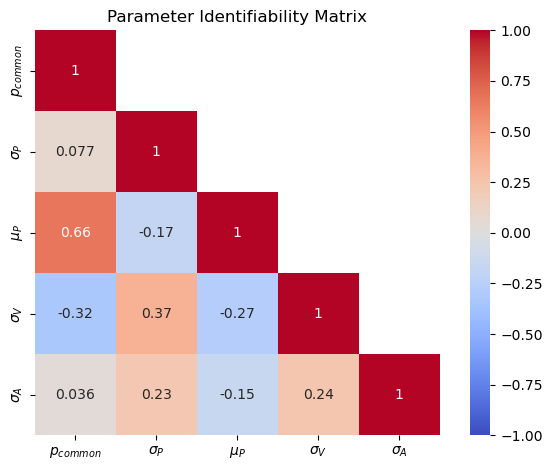

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

parameter_order = ['pcommon', 'sigma_p', 'mu_p', 'sigma_v', 'sigma_a']
parameter_labels = {
    'pcommon': r'$p_{common}$',
    'sigma_p': r'$\sigma_P$',
    'mu_p': r'$\mu_P$',
    'sigma_v': r'$\sigma_V$',
    'sigma_a': r'$\sigma_A$',
}

corr_matrix = df[parameter_order].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=[parameter_labels[p] for p in parameter_order],
    yticklabels=[parameter_labels[p] for p in parameter_order],
)
ax.set_title('Parameter Identifiability Matrix')
plt.tight_layout()
plt.show()

In [8]:
# check if pcommon and sigmap are correlated

df_blindspot = df[df['location'] == 'blindspot']
df_control = df[df['location'] == 'control']

for location, df_loc in zip(['blindspot', 'control'], [df_blindspot, df_control]):
    correlation_res = pg.corr(df_loc['pcommon'], df_loc['sigma_v'])
    print(f"Correlation results for {location}:")
    print(correlation_res)

Correlation results for blindspot:
          n        r          CI95     p_val   BF10     power
pearson  20 -0.06954  [-0.5, 0.38]  0.770808  0.288  0.059178
Correlation results for control:
          n         r            CI95     p_val   BF10     power
pearson  20 -0.458058  [-0.75, -0.02]  0.042252  1.904  0.549242
